In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
loader = torch.utils.data.DataLoader(
    torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=T.ToTensor()),
    batch_size=128, shuffle=True
)

In [8]:
class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(784,128), nn.ReLU(),
            nn.Linear(128,64)
        )
        self.dec = nn.Sequential(
            nn.Linear(64,128), nn.ReLU(),
            nn.Linear(128,784), nn.Sigmoid()
        )

    def forward(self,x):
        x = x.view(-1,784)
        return self.dec(self.enc(x))

In [9]:
dae = DAE().to(device)
opt = torch.optim.Adam(dae.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(5):
    for x,_ in loader:
        x = x.to(device)

        noisy = torch.clamp(x + 0.3*torch.randn_like(x), 0, 1)

        out = dae(noisy)
        loss = loss_fn(out, x.view(-1,784))

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("DAE Epoch:", epoch+1, "Loss:", loss.item())

DAE Epoch: 1 Loss: 0.02661595493555069
DAE Epoch: 2 Loss: 0.021967168897390366
DAE Epoch: 3 Loss: 0.01998445764183998
DAE Epoch: 4 Loss: 0.01839507557451725
DAE Epoch: 5 Loss: 0.015730148181319237


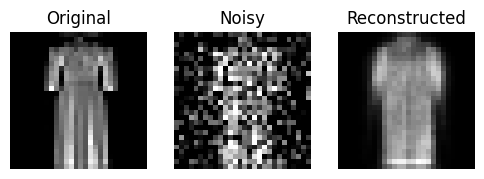

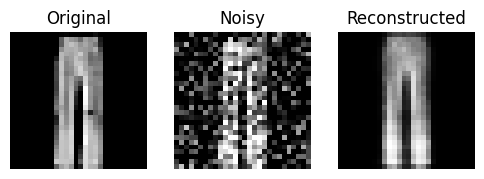

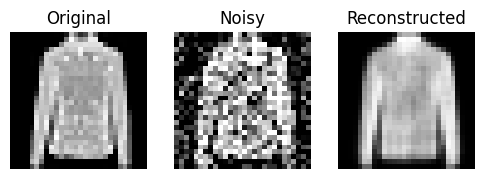

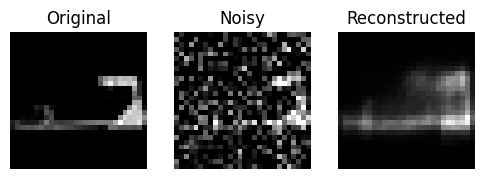

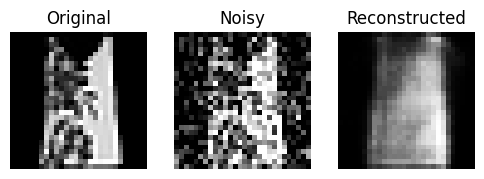

In [10]:
dae.eval()
imgs, _ = next(iter(loader))
imgs = imgs.to(device)

noisy = torch.clamp(imgs + 0.3*torch.randn_like(imgs), 0, 1)

with torch.no_grad():
    recon = dae(noisy).view(-1,1,28,28)

imgs = imgs.cpu()
noisy = noisy.cpu()
recon = recon.cpu()

for i in range(5):
    plt.figure(figsize=(6,2))

    plt.subplot(1,3,1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(noisy[i][0], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(recon[i][0], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

    plt.show()

In [11]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)

        self.mu = nn.Linear(128,20)
        self.logvar = nn.Linear(128,20)

        self.fc2 = nn.Linear(20,128)
        self.fc3 = nn.Linear(128,784)

    def forward(self,x):
        x = x.view(-1,784)
        h = torch.relu(self.fc1(x))

        mu = self.mu(h)
        logvar = self.logvar(h)

        std = torch.exp(0.5*logvar)
        z = mu + std*torch.randn_like(std)

        h = torch.relu(self.fc2(z))
        out = torch.sigmoid(self.fc3(h))

        return out, mu, logvar

In [12]:
def vae_loss(recon,x,mu,logvar):
    x = x.view(-1,784)

    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar))

    return recon_loss + kl

In [13]:
vae = VAE().to(device)
opt = torch.optim.Adam(vae.parameters(), lr=0.001)

for epoch in range(5):
    for x,_ in loader:
        x = x.to(device)

        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("VAE Epoch:", epoch+1, "Loss:", loss.item())

VAE Epoch: 1 Loss: 26175.85546875
VAE Epoch: 2 Loss: 24099.181640625
VAE Epoch: 3 Loss: 25024.677734375
VAE Epoch: 4 Loss: 23546.87890625
VAE Epoch: 5 Loss: 23060.916015625


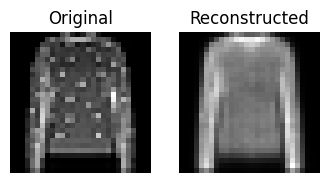

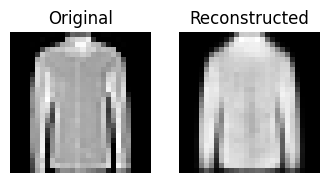

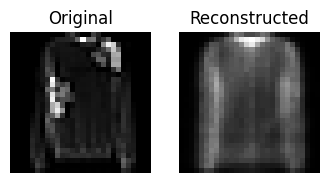

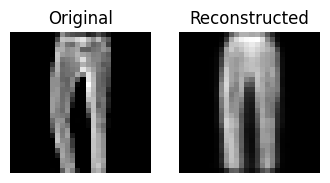

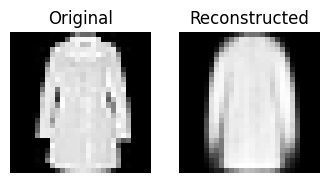

In [14]:
vae.eval()
imgs, _ = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    recon, _, _ = vae(imgs)   # IMPORTANT FIX
    recon = recon.view(-1,1,28,28)

imgs = imgs.cpu()
recon = recon.cpu()

for i in range(5):
    plt.figure(figsize=(4,2))

    plt.subplot(1,2,1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(recon[i][0], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

    plt.show()

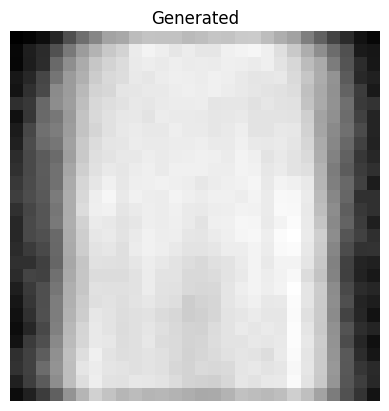

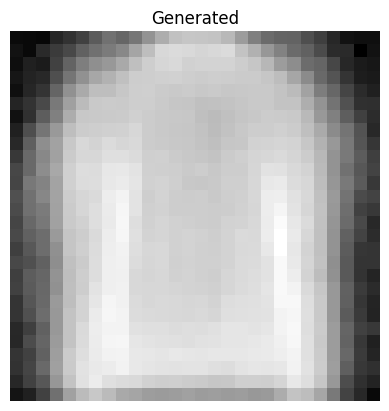

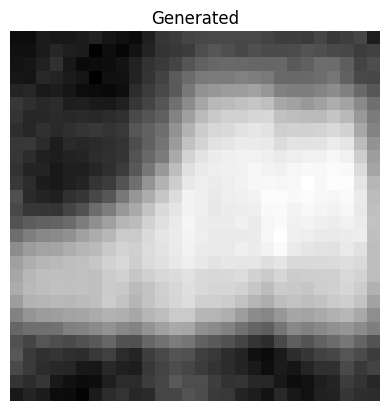

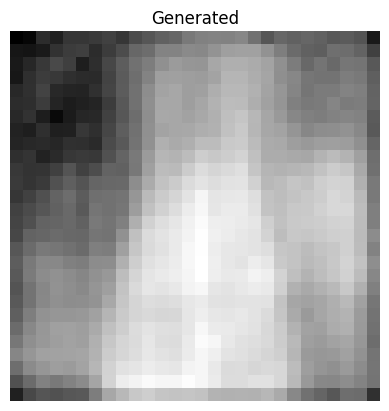

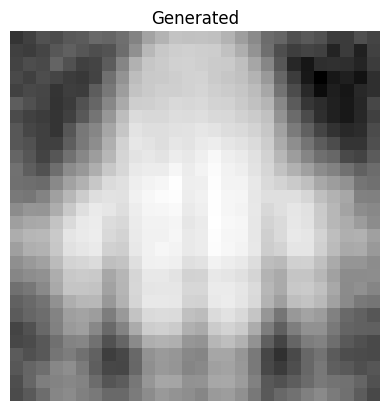

In [15]:
with torch.no_grad():
    z = torch.randn(5,20).to(device)
    samples = vae.fc3(torch.relu(vae.fc2(z))).view(-1,1,28,28)

samples = samples.cpu()

for i in range(5):
    plt.imshow(samples[i][0], cmap='gray')
    plt.title("Generated")
    plt.axis('off')
    plt.show()